Questo codice racchiude i seguenti esperimenti:


*   Train 50%ped2+50%synth - test ped2
*   Train 50%ped2+50%synth - test MED

In questo esperimento i dati sintetici sono stati selezionati manualmente, sulla base della loro somiglianza con le caratteristiche visive e dinamiche presenti nel dataset MED.


In [ ]:
import os
from pathlib import Path
import shutil
import re
import time
import natsort

import cv2
from PIL import Image

import numpy as np
from scipy.io import savemat, loadmat
import scipy.io as sio
import pandas as pd

import torch

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import seaborn as sns


#1-🛠️Clonazione github e connessione a drive per reperire i frames

In [ ]:
%cd /content
!rm -rf astnet #Pulizia
!git clone https://github.com/marco-caruso/astnet.git
%cd astnet

/content
Cloning into 'astnet'...
remote: Enumerating objects: 826, done.
remote: Counting objects: 100% (259/259), done.
remote: Compressing objects: 100% (196/196), done.
remote: Total 826 (delta 210), reused 63 (delta 63), pack-reused 567 (from 1)
Receiving objects: 100% (826/826), 45.16 MiB | 16.88 MiB/s, done.
Resolving deltas: 100% (470/470), done.
/content/astnet


In [ ]:
# Installazione requirements dalla root come richiesto dal README astnet
!pip install -r requirements.txt

ERROR: Ignored the following yanked versions: 2.4.0
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement numpy==1.21.5 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4, 1.17.5, 1.18.0, 1.18.1, 1.18.2, 1.18.3, 1.18.4, 1.18.5, 1.19.0, 1.19.1, 1.19.2, 1.19.3, 1.19.4, 1.19.5, 1.20.0, 1.20.1, 1.20.2, 1.20.3, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.22.2, 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#2-🔗Creazione dei symlink/Copia dei file da drive

##2.1-Ped2

In [ ]:
#!mkdir -p "/content/astnet/data/ped2/training"
!mkdir -p "/content/astnet/data/ped2/testing"

In [ ]:
print("Inizio copia dei frame:")
!cp -r "/content/drive/MyDrive/datasets/ped2/testing/frames" "/content/astnet/data/ped2/testing/frames"

print("Copia del file ground truth...")
!cp "/content/drive/MyDrive/datasets/ped2/ped2.mat" "/content/astnet/data/ped2/ped2.mat"

print("Finito")

Inizio copia dei frame:
Copia del file ground truth...
Finito


In [ ]:
!ls /content/astnet/data/ped2
#!ls /content/astnet/data/ped2/training/frames
!ls /content/astnet/data/ped2/testing/frames

ped2.mat  testing
01  02	03  04	05  06	07  08	09  10	11  12


In [ ]:
paths_to_fix = [
    '/content/astnet/data/ped2/testing/frames/'
]

def rename_local_frames(base_path):
    if not os.path.exists(base_path):
        print(f"Percorso non trovato: {base_path}")
        return

    subdirs = natsort.natsorted(os.listdir(base_path))
    for subdir in subdirs:
        subdir_path = os.path.join(base_path, subdir)
        if not os.path.isdir(subdir_path): continue

        files = natsort.natsorted([f for f in os.listdir(subdir_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        if not files: continue

        # Controlla se il primo è 000
        if "000" in files[0]:
            print(f"Rinomino: {subdir}")
            for file_name in reversed(files):
                old_path = os.path.join(subdir_path, file_name)
                name_part, ext_part = os.path.splitext(file_name)
                try:
                    new_num = int(name_part) + 1
                    new_name = f"{new_num:03d}{ext_part.lower()}"
                    os.rename(old_path, os.path.join(subdir_path, new_name))
                except ValueError: continue
        else:
            print(f"Salta: {subdir} (già corretto)")

for p in paths_to_fix:
    rename_local_frames(p)
print("Rinomina completata in locale!")

Rinomino: 01
Rinomino: 02
Rinomino: 03
Rinomino: 04
Rinomino: 05
Rinomino: 06
Rinomino: 07
Rinomino: 08
Rinomino: 09
Rinomino: 10
Rinomino: 11
Rinomino: 12
Rinomina completata in locale!


##2.2-Synth+ped2

Copiamo i frame di training di ped2+sintetici. In totale risultano 16 video di ped2 e 11 video del dataset sintetico

In [ ]:
#!mkdir -p "/content/astnet/data/synth/training"
!mkdir -p "/content/astnet/data/ped2_synth/training"

In [ ]:

print("Inizio copia dei frame di training:")
!cp -r "/content/drive/MyDrive/datasets/ped2_synth/training/frames" \
      "/content/astnet/data/ped2_synth/training/frames/"
print("Fine copia dei frame di training.")


print("Finito")

Inizio copia dei frame di training:
Fine copia dei frame di training.
Finito


In [ ]:
!ls /content/astnet/data/ped2_synth
!ls /content/astnet/data/ped2_synth/training/frames

training
ped2_01  ped2_05  ped2_09  ped2_13  synth_01  synth_05	synth_09
ped2_02  ped2_06  ped2_10  ped2_14  synth_02  synth_06	synth_10
ped2_03  ped2_07  ped2_11  ped2_15  synth_03  synth_07	synth_11
ped2_04  ped2_08  ped2_12  ped2_16  synth_04  synth_08


Rinominiamo i frames di ped2 per farli partire da 001 invece che da 000

In [ ]:
paths_to_fix = [
    '/content/astnet/data/ped2_synth/training/frames/'
]

def rename_local_frames(base_path):
    if not os.path.exists(base_path):
        print(f"Percorso non trovato: {base_path}")
        return

    subdirs = natsort.natsorted(os.listdir(base_path))
    for subdir in subdirs:
        subdir_path = os.path.join(base_path, subdir)
        if not os.path.isdir(subdir_path): continue

        files = natsort.natsorted([f for f in os.listdir(subdir_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        if not files: continue

        # Controlla se il primo è 000
        if "000" in files[0]:
            print(f"Rinomino: {subdir}")
            for file_name in reversed(files):
                old_path = os.path.join(subdir_path, file_name)
                name_part, ext_part = os.path.splitext(file_name)
                try:
                    new_num = int(name_part) + 1
                    new_name = f"{new_num:03d}{ext_part.lower()}"
                    os.rename(old_path, os.path.join(subdir_path, new_name))
                except ValueError: continue
        else:
            print(f"Salta: {subdir} (già corretto)")

for p in paths_to_fix:
    rename_local_frames(p)
print("Rinomina completata in locale!")

Rinomino: ped2_01
Rinomino: ped2_02
Rinomino: ped2_03
Rinomino: ped2_04
Rinomino: ped2_05
Rinomino: ped2_06
Rinomino: ped2_07
Rinomino: ped2_08
Rinomino: ped2_09
Rinomino: ped2_10
Rinomino: ped2_11
Rinomino: ped2_12
Rinomino: ped2_13
Rinomino: ped2_14
Rinomino: ped2_15
Rinomino: ped2_16
Salta: synth_01 (già corretto)
Salta: synth_02 (già corretto)
Salta: synth_03 (già corretto)
Salta: synth_04 (già corretto)
Salta: synth_05 (già corretto)
Salta: synth_06 (già corretto)
Salta: synth_07 (già corretto)
Salta: synth_08 (già corretto)
Salta: synth_09 (già corretto)
Salta: synth_10 (già corretto)
Salta: synth_11 (già corretto)
Rinomina completata in locale!


##2.3-MED

In [ ]:
!mkdir -p "/content/astnet/data/med/testing"

In [ ]:
print("Inizio copia dei frame:")
!cp -r "/content/drive/MyDrive/datasets/med/testing/frames" "/content/astnet/data/med/testing/frames"

print("Copia del file ground truth...")
!cp "/content/drive/MyDrive/datasets/med/med.mat" "/content/astnet/data/med/med.mat"

print("Finito")

Inizio copia dei frame:
Copia del file ground truth...
Finito


#3-⚙️Training

Il training verrà fatto con il dataset ibrido: 50% ped2 e 50% synth. Risultano 16 video del dataset ped2 (2550 frames) e 11 video del dataset sintetico (2673 frames) per un totale di 5223 frames.

##3.1-Ped2+synth

In [ ]:
%cd /content/astnet/ASTNet
!perl -pi -e 's/\bnp\.float\b/float/g; s/\bnp\.int\b/int/g; s/\bnp\.bool\b/bool/g; s/\bnp\.object\b/object/g' utils/anomaly_util.py

/content/astnet/ASTNet


In [ ]:
!pip install yacs

In [ ]:
# Crea la cartella
!mkdir -p /content/astnet/ASTNet/datasets/seg_weights/

# Copia il file da Drive
!cp /content/drive/MyDrive/datasets/weights/wider_resnet38.pth /content/astnet/ASTNet/datasets/seg_weights/

In [ ]:
#Modificare nel file .yaml: '/content/astnet/ASTNet/datasets/seg_weights/wider_resnet38.pth'

Copiamo l'ultimo checkpoint da cui ripartire

In [ ]:
!mkdir -p /content/astnet/ASTNet/output/ped2_synth/ped2_synth_wresnet/
!cp /content/drive/MyDrive/datasets/Training_Backup/training_ped2_synth/epoch_32.pth /content/astnet/ASTNet/output/ped2_synth/ped2_synth_wresnet/epoch_32.pth

In [ ]:
!python /content/astnet/ASTNet/train.py --cfg /content/astnet/ASTNet/config/ped2_synth_wresnet.yaml

=> creating output/ped2_synth/ped2_synth_wresnet
=> creating log/ped2_synth/wrn38/ped2_synth_wresnet_2026-02-10-10-02
Namespace(cfg='/content/astnet/ASTNet/config/ped2_synth_wresnet.yaml', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 2, 'PRINT_FREQ': 20, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/astnet/data/', 'DATASET': 'ped2_synth', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 2, 'LOWER_BOUND': 0}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 2, 'SHUFFLE': True, 'BEGIN_EPOCH': 32, 'END_EPOCH': 80, 'RESUME': True, 'CHECKPOINT': '/content/astnet/ASTNet/output/ped2_synth/ped2_synth_wresnet/epoch_32.pth', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [50, 65], 'LR_FACTOR': 

Copia un epoca specifica su drive

In [ ]:
!cp '/content/astnet/ASTNet/output/ped2_synth/ped2_synth_wresnet/epoch_35.pth' '/content/drive/MyDrive/datasets/Training_Backup/training_ped2_synth'

###Recap del training e copia del file .pth in locale per il testing

Epoca 40 con learning rate di 0.0002

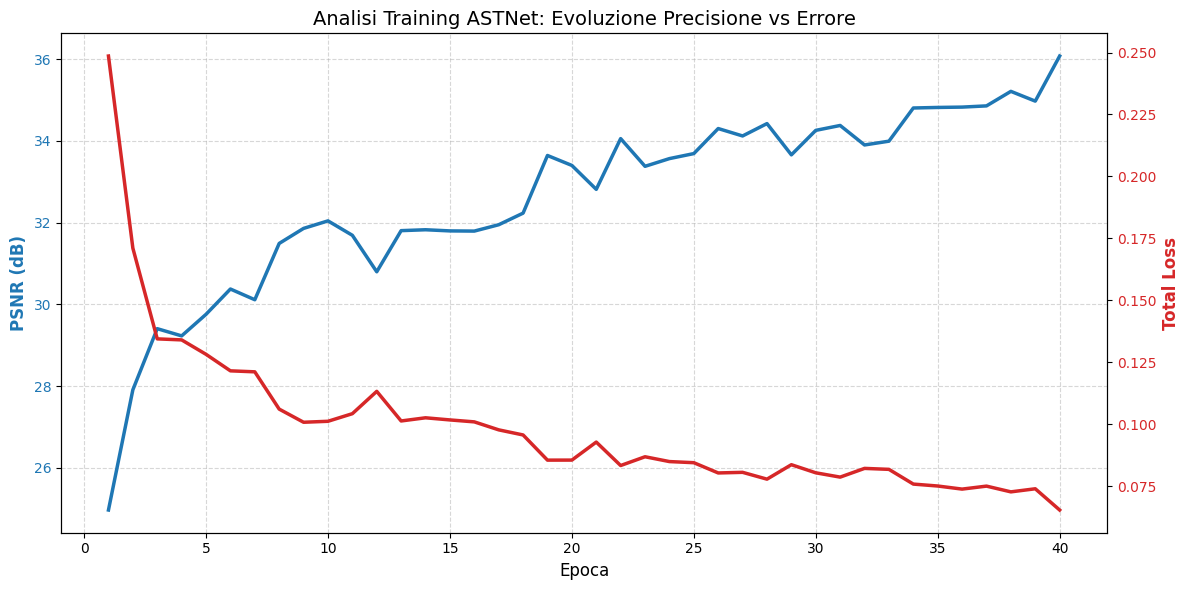

In [ ]:

log_files = [
    "/content/drive/MyDrive/datasets/Training_Backup/training_ped2_synth/[1-15]ped2_synth_wresnet_2026-02-09-11-51_train.log",
    "/content/drive/MyDrive/datasets/Training_Backup/training_ped2_synth/[16-32]ped2_synth_wresnet_2026-02-09-22-38_train.log",
    "/content/drive/MyDrive/datasets/Training_Backup/training_ped2_synth/[33-40]ped2_synth_wresnet_2026-02-10-10-02_train.log"
]

def plot_training_results(files):
    data = []
    # Pattern per catturare Epoca, le 4 componenti della Loss e il PSNR
    pattern = re.compile(r"Epoch: \[(\d+)\]\[\d+/\d+\].*?inte ([\d\.]+) \+ grad ([\d\.]+) \+ msssim ([\d\.]+) \+ L2 ([\d\.]+)\].*?PSNR ([\d\.]+)")

    for f_path in files:
        with open(f_path, 'r') as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    epoch = int(match.group(1))
                    # Loss Totale = somma delle 4 componenti
                    total_loss = float(match.group(2)) + float(match.group(3)) + \
                                 float(match.group(4)) + float(match.group(5))
                    psnr = float(match.group(6))
                    data.append({'Epoch': epoch, 'Loss': total_loss, 'PSNR': psnr})

    if not data:
        print("Nessun dato trovato. Controlla i percorsi dei file.")
        return

    # Tabella e calcolo media per epoca
    df = pd.DataFrame(data).groupby('Epoch').mean().reset_index()

    # Grafico
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Blu: PSNR (asse sinistro)
    ax1.set_xlabel('Epoca', fontsize=12)
    ax1.set_ylabel('PSNR (dB)', color='tab:blue', fontsize=12, fontweight='bold')
    ax1.plot(df['Epoch'], df['PSNR'], color='tab:blue', label='PSNR (Qualità)', linewidth=2.5)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Rosso: Total Loss (asse destro)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Total Loss', color='tab:red', fontsize=12, fontweight='bold')
    ax2.plot(df['Epoch'], df['Loss'], color='tab:red', label='Loss (Errore)', linewidth=2.5)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    plt.title('Analisi Training ASTNet: Evoluzione Precisione vs Errore', fontsize=14)
    fig.tight_layout()
    plt.show()


plot_training_results(log_files)

###Copia in locale del modello trainato

In [ ]:
!cp /content/drive/MyDrive/datasets/Training_Backup/training_ped2_synth/epoch_15.pth /content/astnet/ASTNet/epoch_15.pth

print("File copiato con successo!")

#4-📝Testing

Operazioni preliminari per evitare errori di tipo

In [ ]:
%cd /content/astnet/ASTNet
!perl -pi -e 's/\bnp\.float\b/float/g; s/\bnp\.int\b/int/g; s/\bnp\.bool\b/bool/g; s/\bnp\.object\b/object/g' utils/anomaly_util.py

In [ ]:
!pip install yacs

UTILIZZIAMO FRAME_STEPS=2

##4.1-Test ped2

In [ ]:
%cd /content/astnet/ASTNet
!python test.py \
  --cfg config/ped2_wresnet.yaml \
  --model-file output/ped2_synth/ped2_synth_wresnet/epoch_40.pth

/content/astnet/ASTNet
=> creating output/ped2/ped2_wresnet
=> creating log/ped2/wrn38/ped2_wresnet_2026-02-10-15-34
Namespace(cfg='config/ped2_wresnet.yaml', model_file='output/ped2_synth/ped2_synth_wresnet/epoch_40.pth', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 2, 'PRINT_FREQ': 1, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/drive/MyDrive/datasets', 'DATASET': 'ped2', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 2, 'LOWER_BOUND': 100}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 2, 'SHUFFLE': True, 'BEGIN_EPOCH': 0, 'END_EPOCH': 120, 'RESUME': True, 'CHECKPOINT': '', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [80, 100], 'LR_FACTOR': 0.5}), 'TEST': CfgNode({'BATCH_S

Salvataggio del test su drive

In [ ]:
!cp -r /content/astnet/ASTNet/output/ped2 /content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth

##4.3-Test MED

In [ ]:
%cd /content/astnet/ASTNet
!python test.py \
  --cfg config/med_wresnet.yaml \
  --model-file output/ped2_synth/ped2_synth_wresnet/epoch_40.pth

/content/astnet/ASTNet
=> creating output/med/med_wresnet
=> creating log/med/wrn38/med_wresnet_2026-02-10-16-14
Namespace(cfg='config/med_wresnet.yaml', model_file='output/ped2_synth/ped2_synth_wresnet/epoch_40.pth', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 0, 'PRINT_FREQ': 1, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/astnet/data/', 'DATASET': 'med', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 2, 'LOWER_BOUND': 0}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 2, 'SHUFFLE': True, 'BEGIN_EPOCH': 0, 'END_EPOCH': 120, 'RESUME': True, 'CHECKPOINT': '', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [80, 100], 'LR_FACTOR': 0.5}), 'TEST': CfgNode({'BATCH_SIZE_PER_GPU': 1}),

In [ ]:
!cp -r /content/astnet/ASTNet/output/med /content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth/

#5-📈Results

##5.1 Ped2

###Plot

Soglia globale ottimale (Youden) per Ped2: 0.2891
Numero totale di video trovati: 12


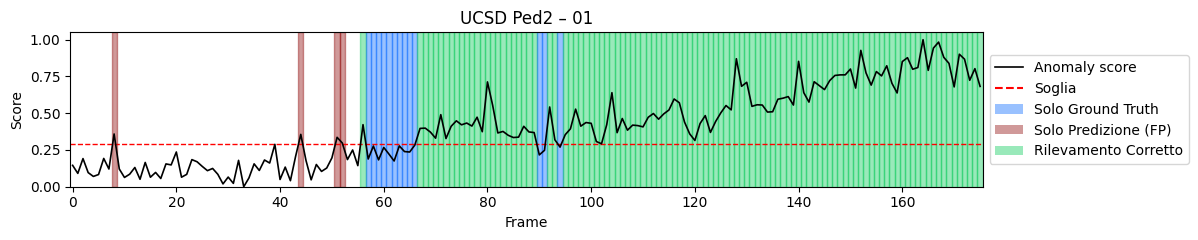

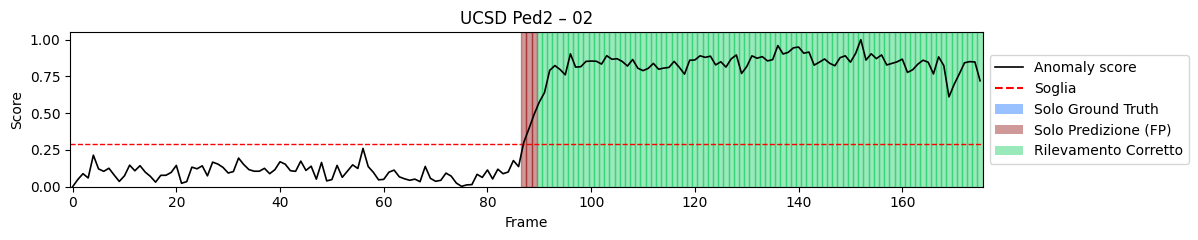

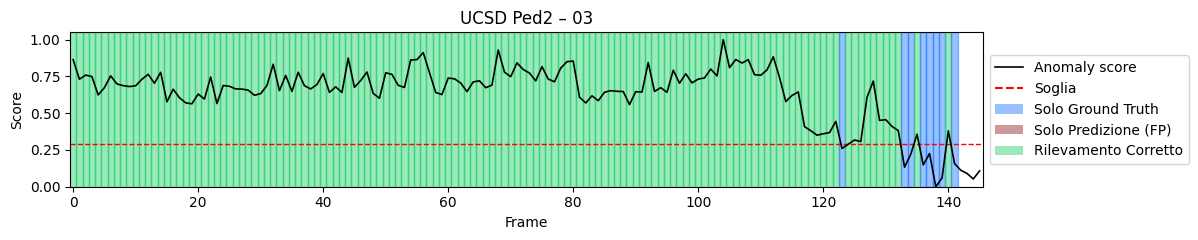

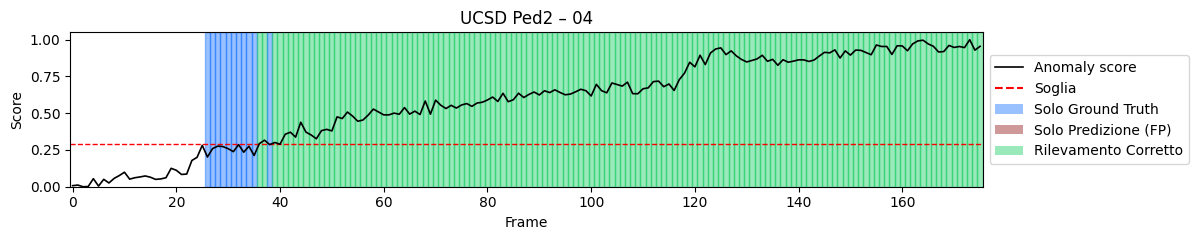

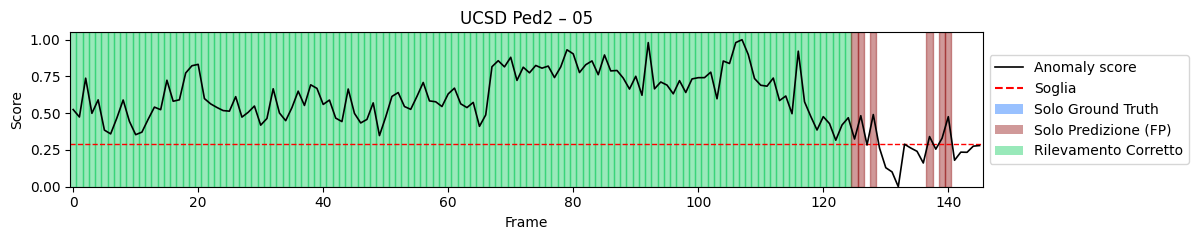

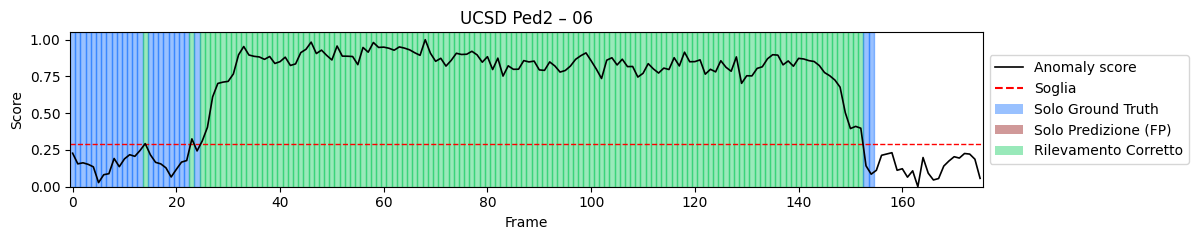

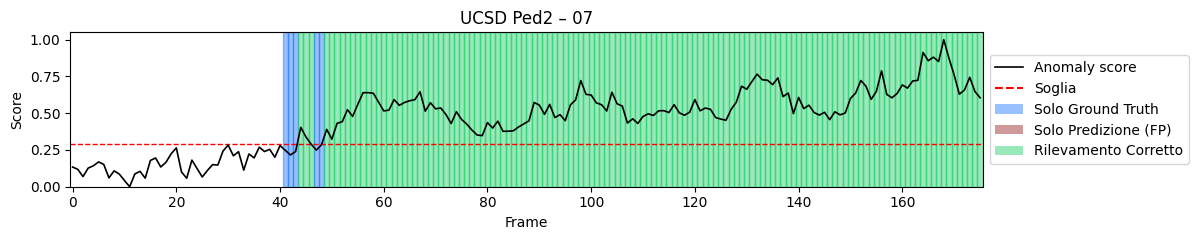

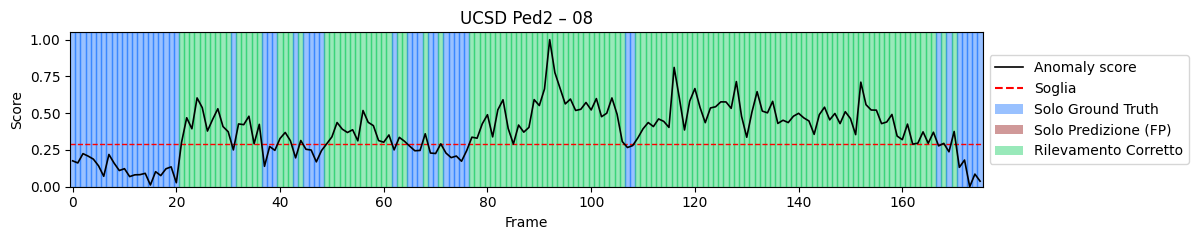

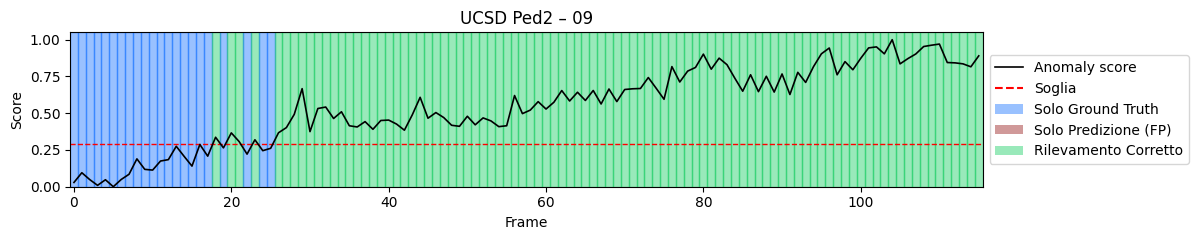

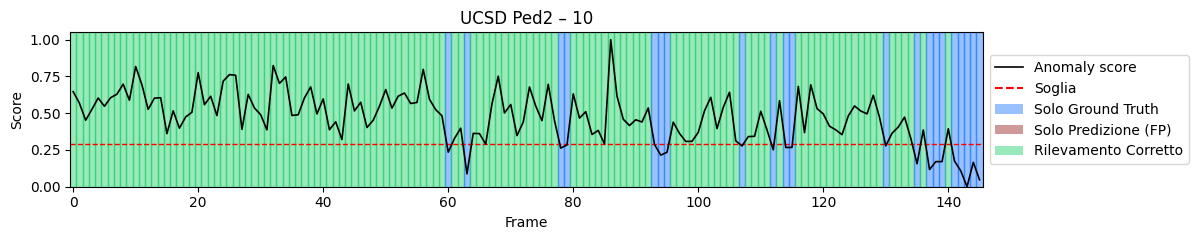

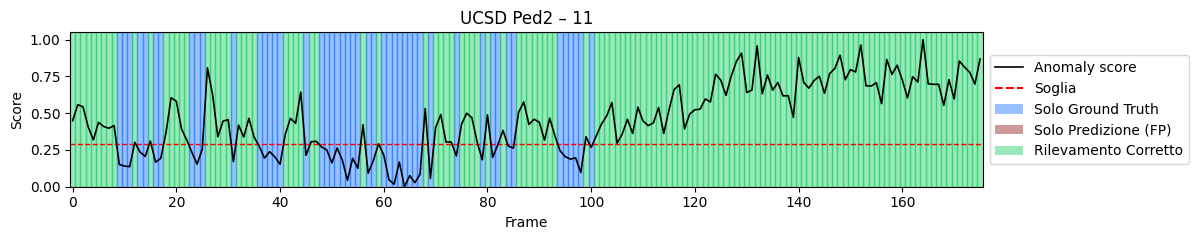

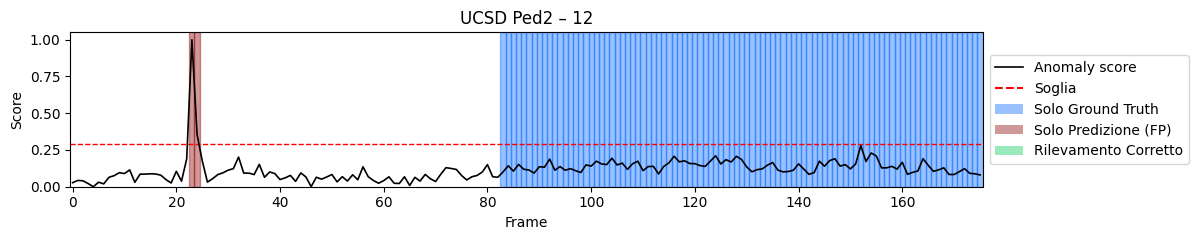

In [ ]:

OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth/ped2/ped2_wresnet")
FRAMES_DIR = Path("/content/drive/MyDrive/datasets/ped2/testing/frames")

# Caricamento dei dati dai file .npy generati dal test
try:
    psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)
except FileNotFoundError:
    psnr_list = np.load(OUT_DIR / "psnr.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt.npy", allow_pickle=True)

# Recupero nomi delle cartelle video
video_names = sorted([p.name for p in FRAMES_DIR.iterdir() if p.is_dir()])

fp = 4  # encoded_frames + decoded_frames


# Score continuo
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    # Normalizzazione Min-Max invertita (PSNR basso = Score alto)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

#-------
# Calcolo soglia globale dal ROC (Youden J)
#-------
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)
    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

fpr, tpr, thr = roc_curve(all_gts, all_scores)
best_thr = thr[np.argmax(tpr - fpr)]
print(f"Soglia globale ottimale (Youden) per Ped2: {best_thr:.4f}")

#-------
# Plot
#-------
def plot_video_ped2(idx, thr=best_thr):
    psnr_video = psnr_list[idx]
    score = anomaly_score_from_psnr(psnr_video)

    gt_aligned = align_gt_to_psnr(gt_list[idx], psnr_video, fp)
    pred = (score >= thr).astype(int)

    L = min(len(score), len(gt_aligned), len(pred))
    score = score[:L]
    gt_aligned = gt_aligned[:L]
    pred = pred[:L]

    # Gestione nome video
    name = video_names[idx] if idx < len(video_names) else f"Video {idx+1}"

    colors = np.empty(L, dtype=object)
    colors[:] = 'none'

    # Blu: Anomalia reale non vista (False Negative)
    colors[(gt_aligned == 1) & (pred == 0)] = '#0066FF'
    # Rosso: Allarme dove non c'è anomalia (False Positive)
    colors[(pred == 1) & (gt_aligned == 0)] = '#8B0000'
    # Verde: Anomalia rilevata correttamente (True Positive)
    colors[(gt_aligned == 1) & (pred == 1)] = '#00C853'

    fig, ax = plt.subplots(figsize=(12, 2.5))

    ax.plot(score, color="black", linewidth=1.2, label="Anomaly score", zorder=3)
    ax.axhline(y=thr, color='red', linestyle='--', linewidth=1, label='Soglia', zorder=2)

    for i in range(L):
        if colors[i] != 'none':
            ax.axvspan(i-0.5, i+0.5, ymin=0, ymax=1,
                       color=colors[i], alpha=0.4, zorder=1)

    legend_elements = [
        plt.Line2D([0], [0], color='black', linewidth=1.2, label='Anomaly score'),
        plt.Line2D([0], [0], color='red', linestyle='--', label='Soglia'),
        Patch(facecolor='#0066FF', alpha=0.4, label='Solo Ground Truth'),
        Patch(facecolor='#8B0000', alpha=0.4, label='Solo Predizione (FP)'),
        Patch(facecolor='#00C853', alpha=0.4, label='Rilevamento Corretto')
    ]

    ax.set_title(f"UCSD Ped2 – {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, L-0.5)
    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Esecuzione finale
num_videos = len(psnr_list)
print(f"Numero totale di video trovati: {num_videos}")

for i in range(num_videos):
    plot_video_ped2(i)

###ROC CURVE

N video psnr: 12
N video gt: 12
AUC complessiva (PED2): 93.9%


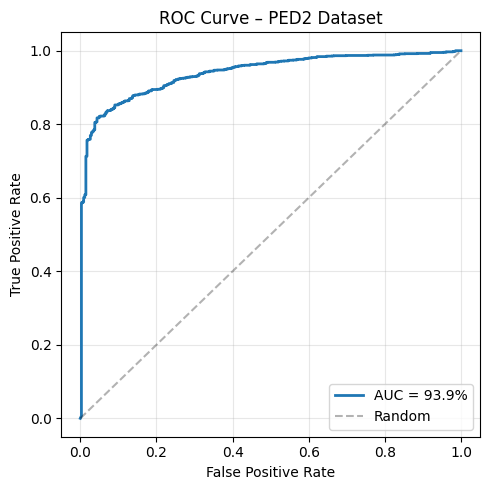

In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth/ped2/ped2_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

print("N video psnr:", len(psnr_list))
print("N video gt:", len(gt_list))

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcola scores
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola AUC
auc = roc_auc_score(all_gts, all_scores)
print(f"AUC complessiva (PED2): {auc * 100:.1f}%")

# ROC
fpr, tpr, _ = roc_curve(all_gts, all_scores)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc*100:.1f}%", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – PED2 Dataset")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Confusion matrix

Soglia ottimale (Youden): 0.2891

=== METRICHE PED2 ===
Accuracy:  84.15%
Precision: 98.88%
Recall:    81.73%
F1-Score:  89.49%

Matrice di Confusione:
[[ 327   15]
 [ 296 1324]]


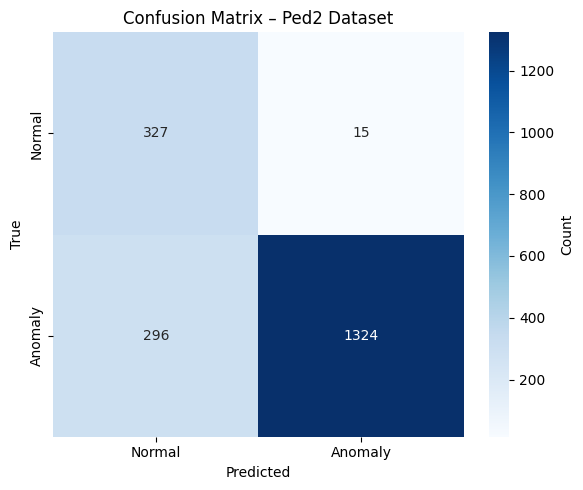


Dettagli:
True Negatives:  327
False Positives: 15
False Negatives: 296
True Positives:  1324


In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth/ped2/ped2_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definisci le funzioni
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcolo degli scores e GT
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola soglia ottimale (Youden index)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_gts, all_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Soglia ottimale (Youden): {best_threshold:.4f}")

# Predizioni binarie
y_pred = (all_scores >= best_threshold).astype(int)

# Calcola metriche
accuracy = accuracy_score(all_gts, y_pred)
precision = precision_score(all_gts, y_pred)
recall = recall_score(all_gts, y_pred)
f1 = f1_score(all_gts, y_pred)

print("\n=== METRICHE PED2 ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

# Matrice di confusione
cm = confusion_matrix(all_gts, y_pred)
print("\nMatrice di Confusione:")
print(cm)

# Plot matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Ped2 Dataset')
plt.tight_layout()
plt.show()

# Stampa dettagli matrice
tn, fp, fn, tp = cm.ravel()
print("\nDettagli:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

##5.2 MED

###Plot

Soglia globale ottimale (Youden) per MED: 0.3571
Numero totale di video trovati: 31


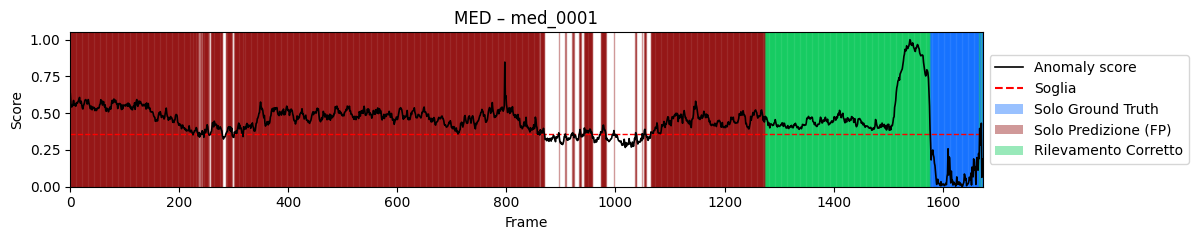

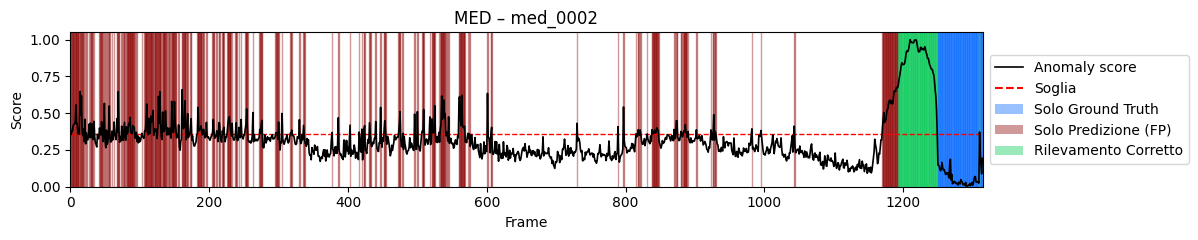

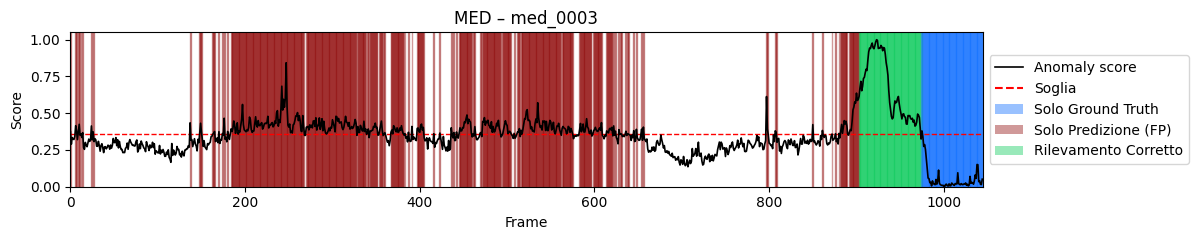

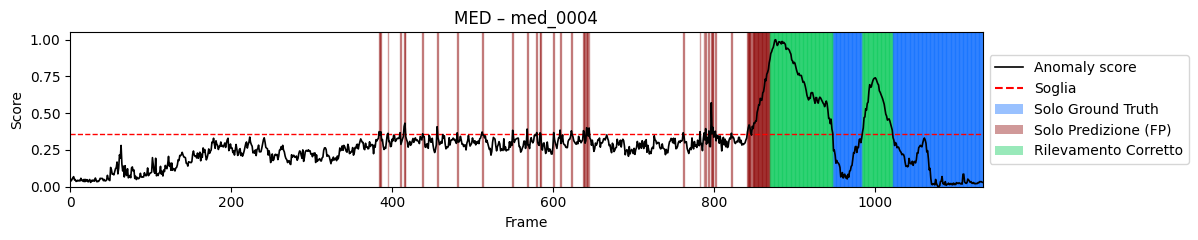

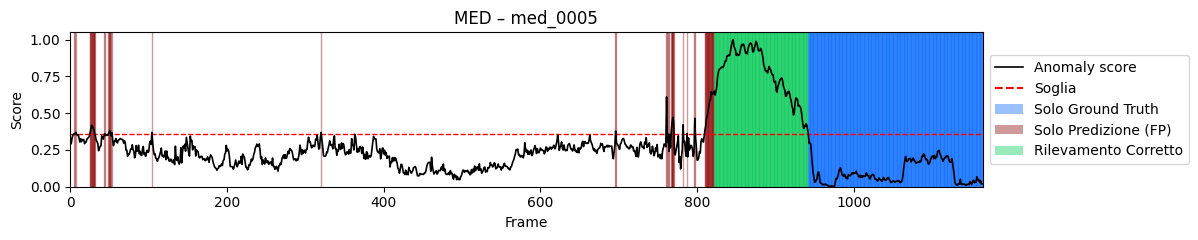

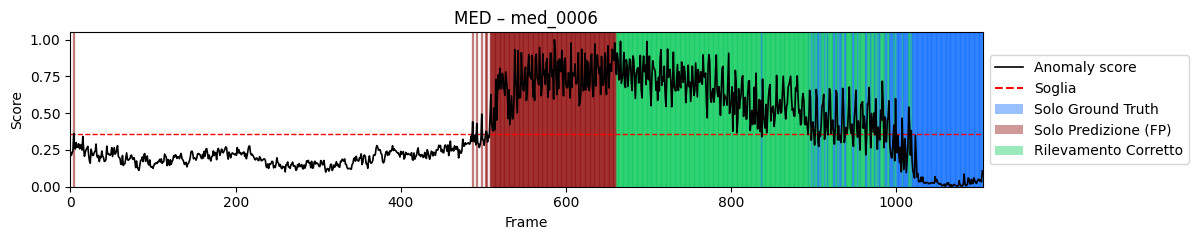

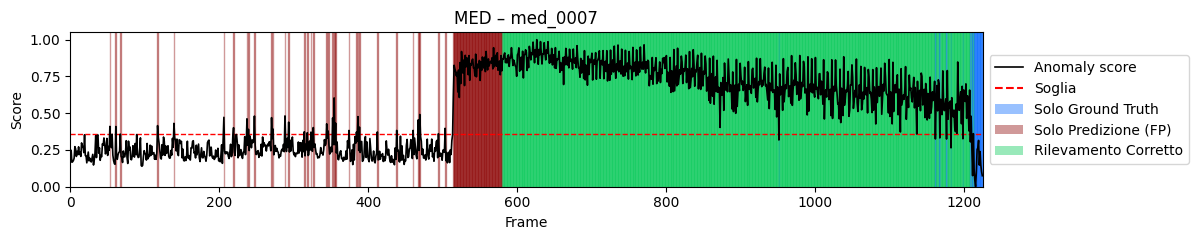

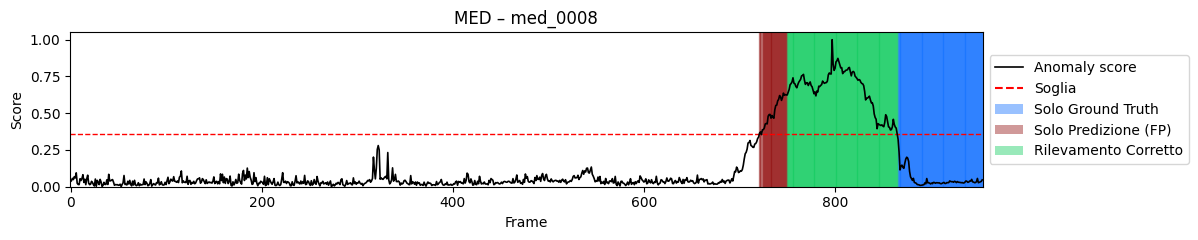

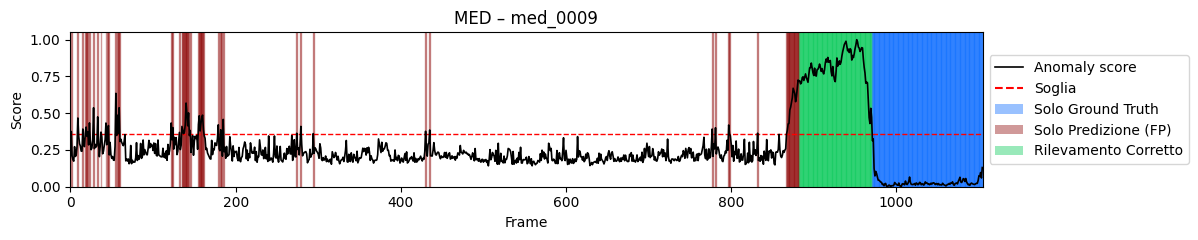

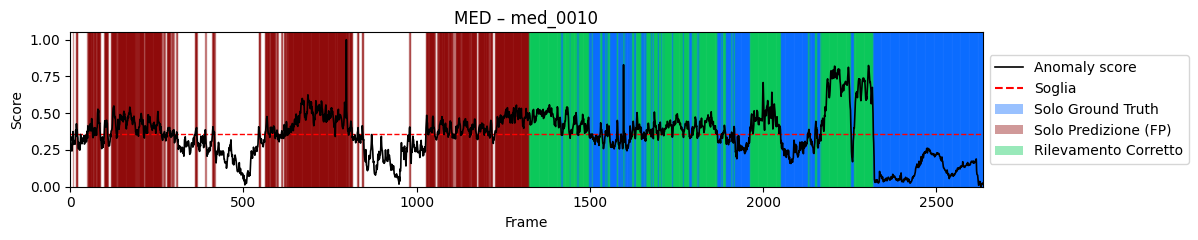

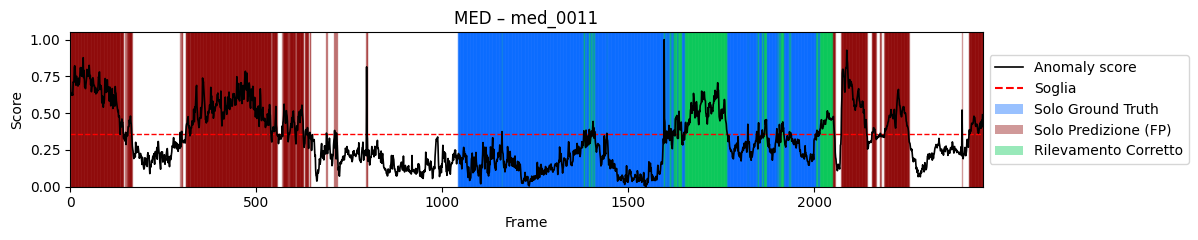

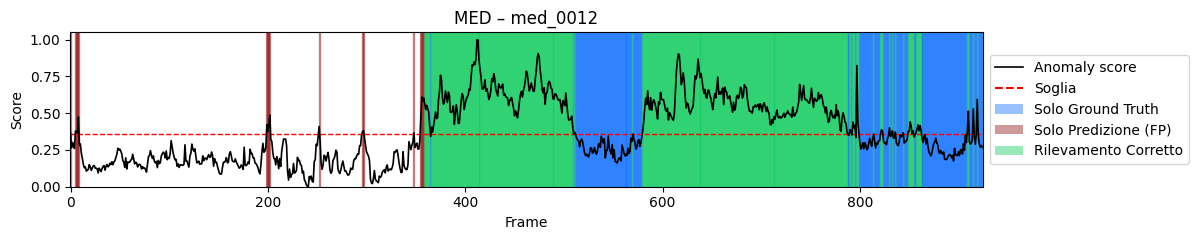

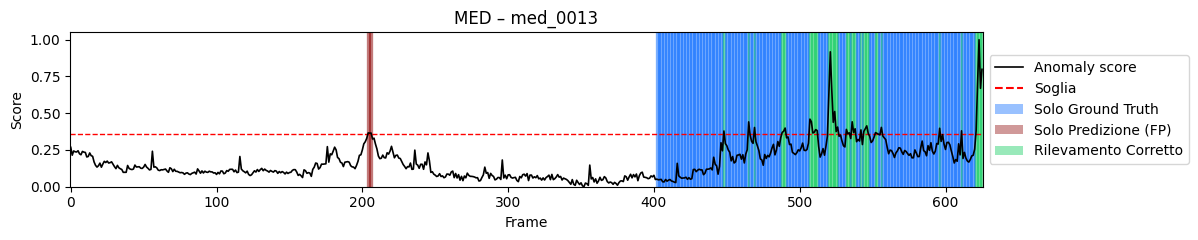

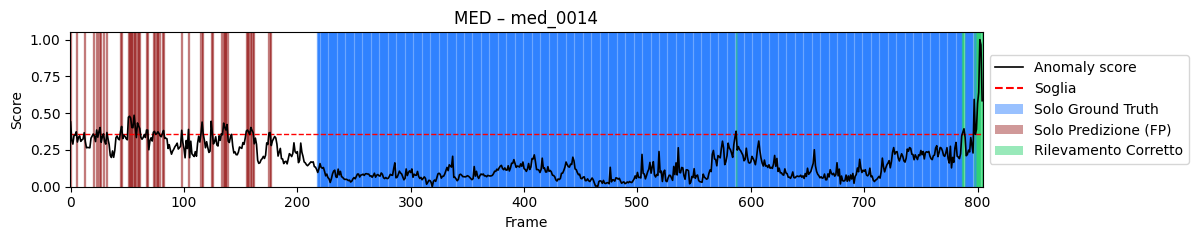

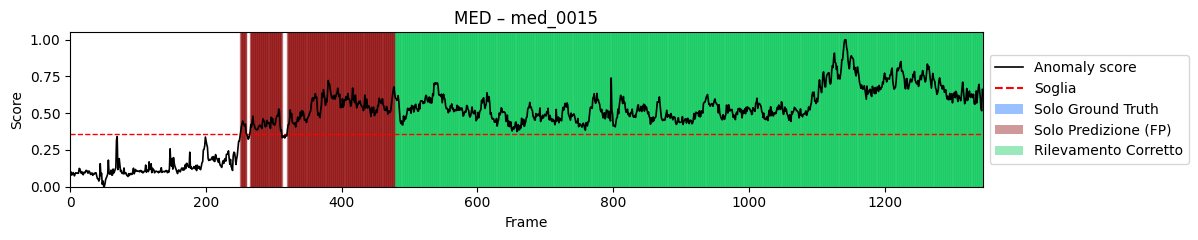

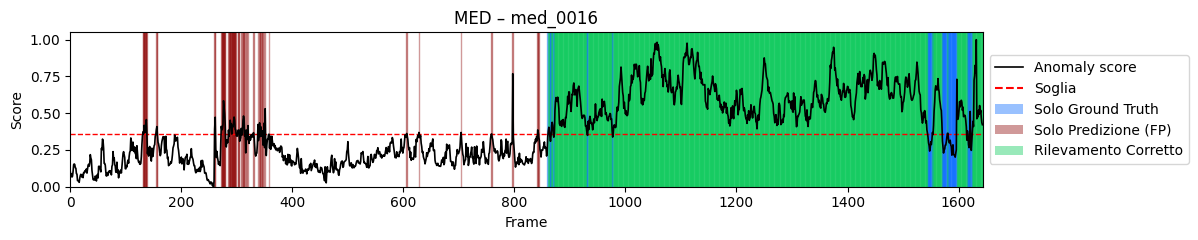

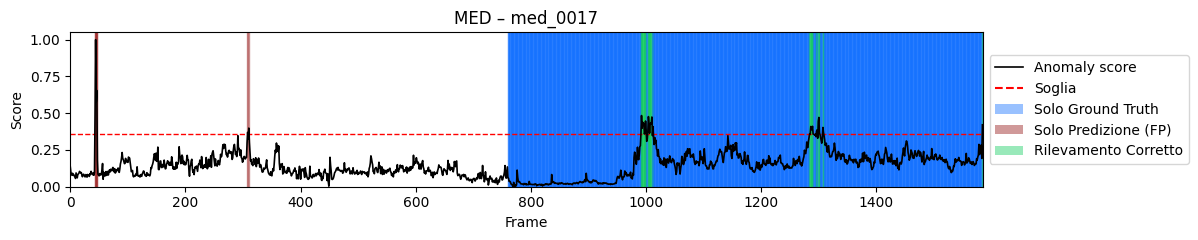

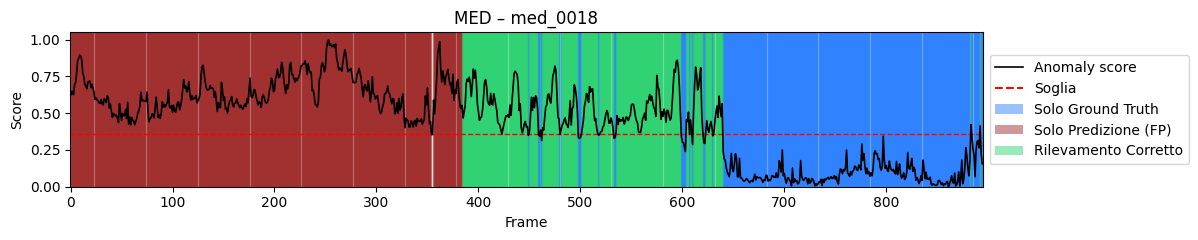

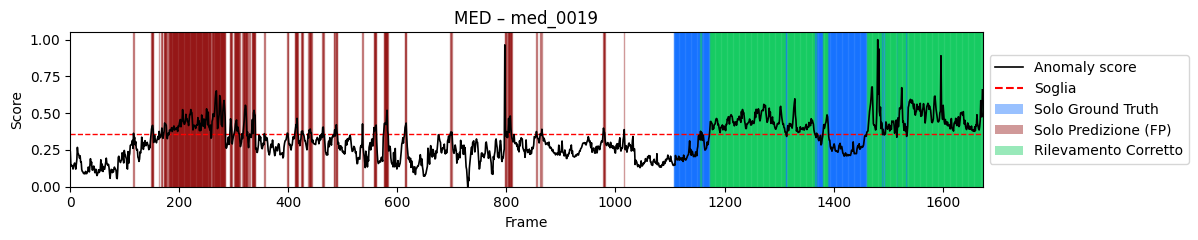

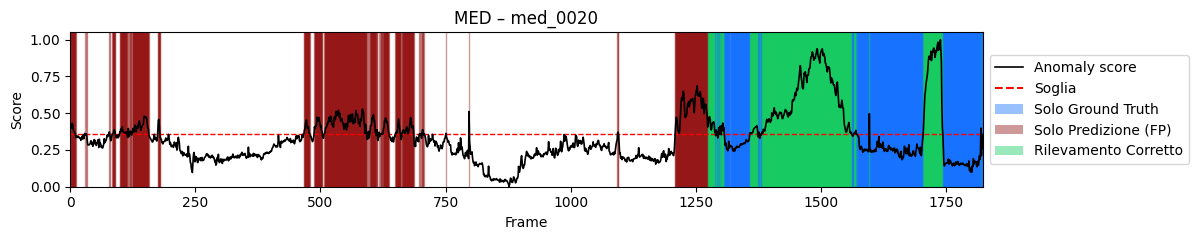

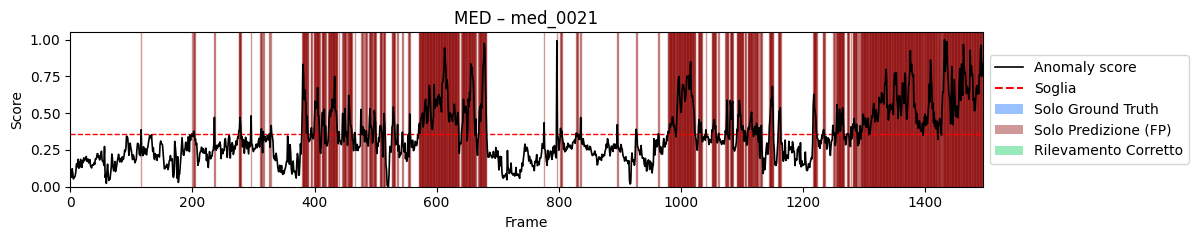

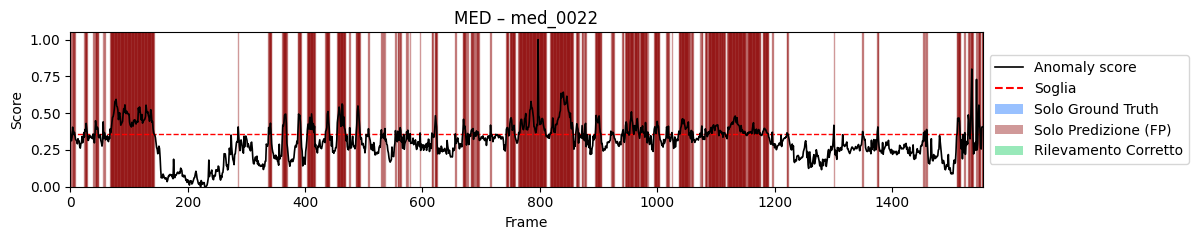

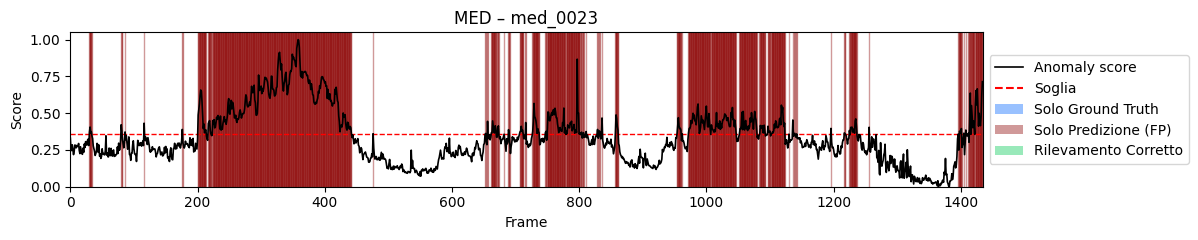

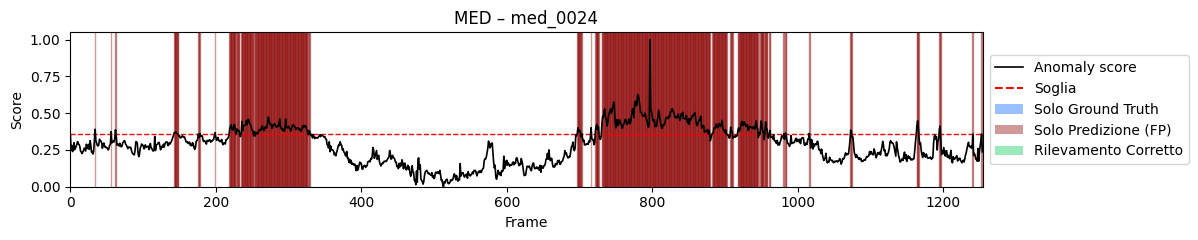

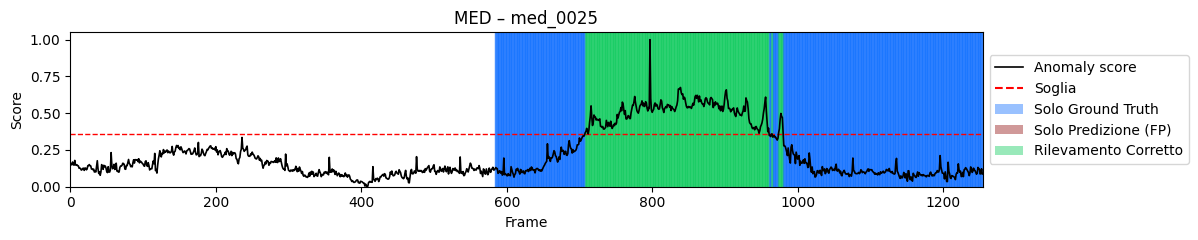

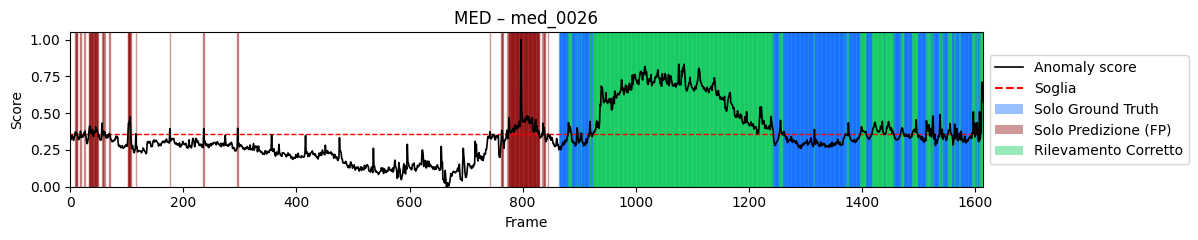

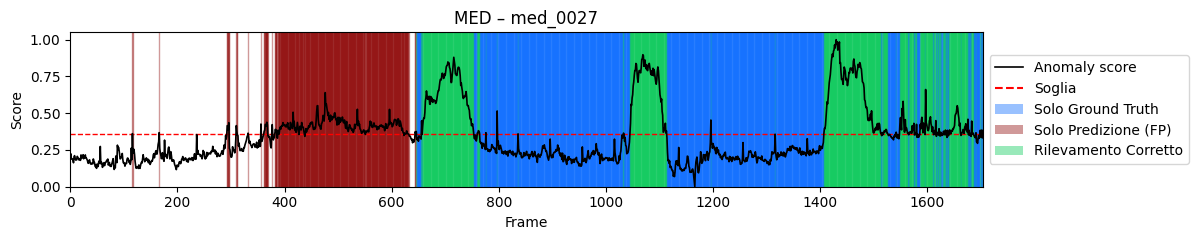

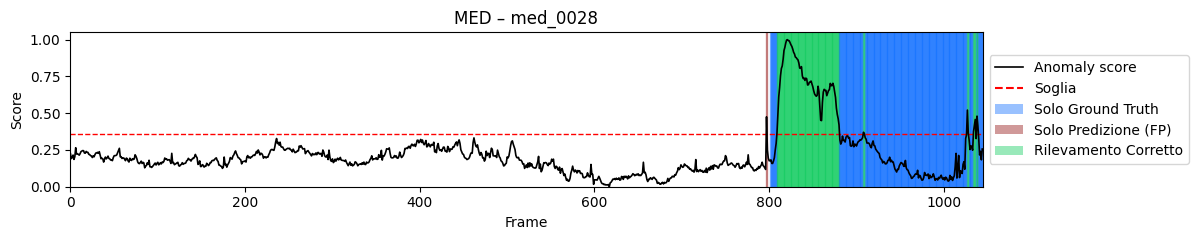

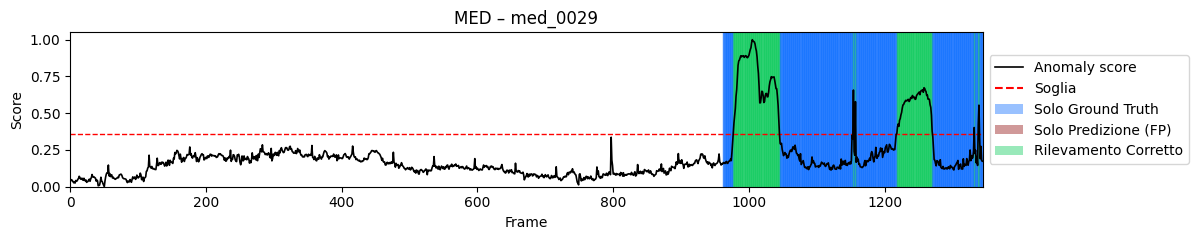

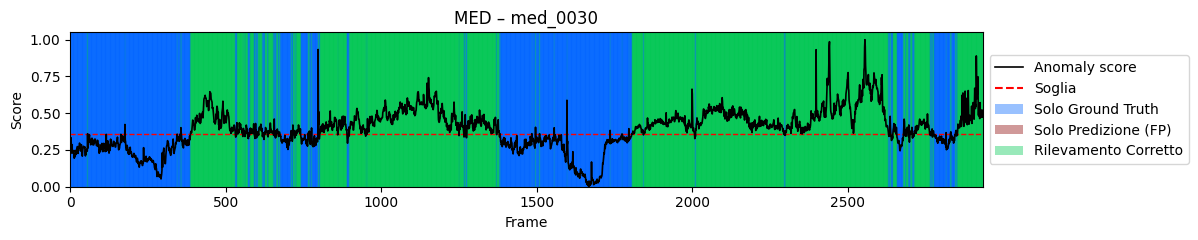

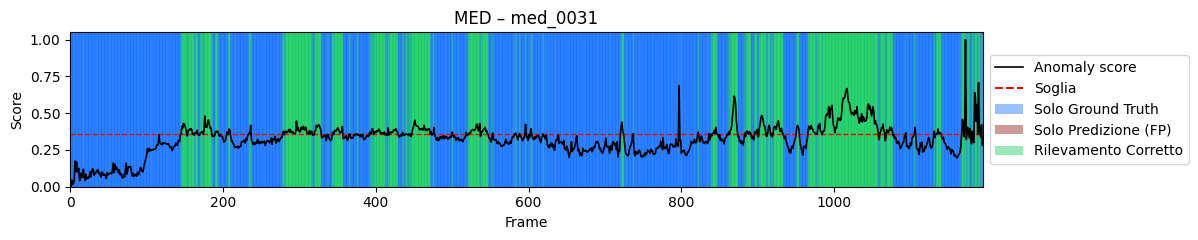

In [ ]:

OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth/med/med_wresnet")
FRAMES_DIR = Path("/content/drive/MyDrive/datasets/med/testing/frames")

# Caricamento dei dati dai file .npy generati dal test
try:
    psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)
except FileNotFoundError:
    psnr_list = np.load(OUT_DIR / "psnr.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt.npy", allow_pickle=True)

# Recupero nomi delle cartelle video
video_names = sorted([p.name for p in FRAMES_DIR.iterdir() if p.is_dir()])

fp = 4  # encoded_frames + decoded_frames


# Score continuo
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    # Normalizzazione Min-Max invertita (PSNR basso = Score alto)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

#-------
# Calcolo soglia globale dal ROC (Youden J)
#-------
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)
    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

fpr, tpr, thr = roc_curve(all_gts, all_scores)
best_thr = thr[np.argmax(tpr - fpr)]
print(f"Soglia globale ottimale (Youden) per MED: {best_thr:.4f}")

#-------
# Plot
#-------
def plot_video_ped2(idx, thr=best_thr):
    psnr_video = psnr_list[idx]
    score = anomaly_score_from_psnr(psnr_video)

    gt_aligned = align_gt_to_psnr(gt_list[idx], psnr_video, fp)
    pred = (score >= thr).astype(int)

    L = min(len(score), len(gt_aligned), len(pred))
    score = score[:L]
    gt_aligned = gt_aligned[:L]
    pred = pred[:L]

    # Gestione nome video
    name = video_names[idx] if idx < len(video_names) else f"Video {idx+1}"

    colors = np.empty(L, dtype=object)
    colors[:] = 'none'

    # Blu: Anomalia reale non vista (False Negative)
    colors[(gt_aligned == 1) & (pred == 0)] = '#0066FF'
    # Rosso: Allarme dove non c'è anomalia (False Positive)
    colors[(pred == 1) & (gt_aligned == 0)] = '#8B0000'
    # Verde: Anomalia rilevata correttamente (True Positive)
    colors[(gt_aligned == 1) & (pred == 1)] = '#00C853'

    fig, ax = plt.subplots(figsize=(12, 2.5))

    ax.plot(score, color="black", linewidth=1.2, label="Anomaly score", zorder=3)
    ax.axhline(y=thr, color='red', linestyle='--', linewidth=1, label='Soglia', zorder=2)

    for i in range(L):
        if colors[i] != 'none':
            ax.axvspan(i-0.5, i+0.5, ymin=0, ymax=1,
                       color=colors[i], alpha=0.4, zorder=1)

    legend_elements = [
        plt.Line2D([0], [0], color='black', linewidth=1.2, label='Anomaly score'),
        plt.Line2D([0], [0], color='red', linestyle='--', label='Soglia'),
        Patch(facecolor='#0066FF', alpha=0.4, label='Solo Ground Truth'),
        Patch(facecolor='#8B0000', alpha=0.4, label='Solo Predizione (FP)'),
        Patch(facecolor='#00C853', alpha=0.4, label='Rilevamento Corretto')
    ]

    ax.set_title(f"MED – {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, L-0.5)
    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Esecuzione finale
num_videos = len(psnr_list)
print(f"Numero totale di video trovati: {num_videos}")

for i in range(num_videos):
    plot_video_ped2(i)

###ROC CURVE

N video psnr: 31
N video gt: 31
AUC complessiva (MED): 63.2%


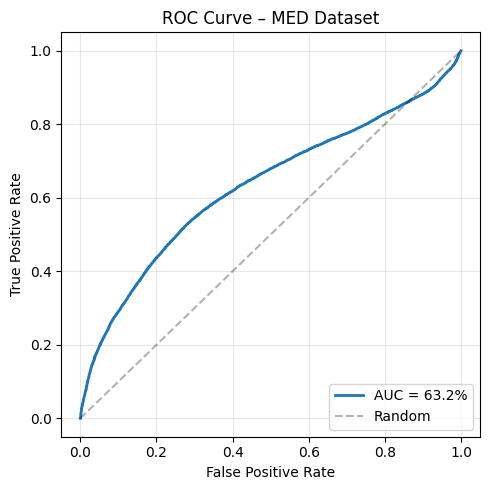

In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth/med/med_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

print("N video psnr:", len(psnr_list))
print("N video gt:", len(gt_list))

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcola scores
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola AUC
auc = roc_auc_score(all_gts, all_scores)
print(f"AUC complessiva (MED): {auc * 100:.1f}%")

# ROC
fpr, tpr, _ = roc_curve(all_gts, all_scores)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc*100:.1f}%", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MED Dataset")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Confusion matrix

Soglia ottimale (Youden): 0.3571

=== METRICHE MED ===
Accuracy:  64.33%
Precision: 56.48%
Recall:    52.17%
F1-Score:  54.24%

Matrice di Confusione:
[[18991  7160]
 [ 8522  9294]]


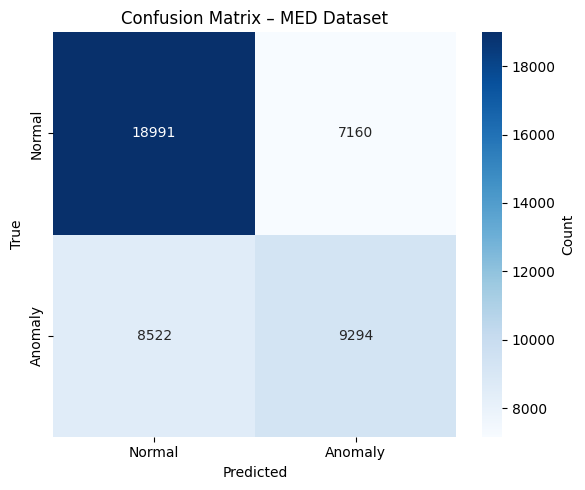


Dettagli:
True Negatives:  18991
False Positives: 7160
False Negatives: 8522
True Positives:  9294


In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth/med/med_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definisci le funzioni
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcolo degli scores e GT
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola soglia ottimale (Youden index)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_gts, all_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Soglia ottimale (Youden): {best_threshold:.4f}")

# Predizioni binarie
y_pred = (all_scores >= best_threshold).astype(int)

# Calcola metriche
accuracy = accuracy_score(all_gts, y_pred)
precision = precision_score(all_gts, y_pred)
recall = recall_score(all_gts, y_pred)
f1 = f1_score(all_gts, y_pred)

print("\n=== METRICHE MED ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

# Matrice di confusione
cm = confusion_matrix(all_gts, y_pred)
print("\nMatrice di Confusione:")
print(cm)

# Plot matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – MED Dataset')
plt.tight_layout()
plt.show()

# Stampa dettagli matrice
tn, fp, fn, tp = cm.ravel()
print("\nDettagli:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")